<a href="https://colab.research.google.com/github/elshafir8/Sistem-Skripsi-Sawi-Hijau/blob/main/Pengujian_TA_ElshaFirlie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Update Dataset

In [8]:
import pandas as pd

# Membaca Dataset
df = pd.read_excel("dataset_sawi_hijau.xlsx")

# Mengkonverikan ke nilai numerik
kolom = ["pH", "kelembaban", "suhu", "N", "P", "K"]

for c in kolom:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=kolom)

# Fungsi Skor pH
def skor_pH(x):
    if 6.0 <= x <= 7.0:
        return 1.00
    elif 5.5 <= x < 6.0 or 7.0 < x <= 7.5:
        return 0.75
    elif 5.0 <= x < 5.5 or 7.5 < x <= 8.0:
        return 0.50
    else:
        return 0.25
# Fungsi Skor Kelembaban
def skor_kelembaban(x):
    if 50 <= x <= 70:
        return 1.00
    elif 40 <= x < 50 or 70 < x <= 80:
        return 0.75
    elif 30 <= x < 40 or 80 < x <= 90:
        return 0.50
    else:
        return 0.25
# Fungsi Skor Suhu
def skor_suhu(x):
    if 20 <= x <= 28:
        return 1.00
    elif 18 <= x < 20 or 28 < x <= 30:
        return 0.75
    elif 16 <= x < 18 or 30 < x <= 32:
        return 0.50
    else:
        return 0.25
# Fungsi Skor Nitrogen
def skor_N(x):
    if 50 <= x <= 125:
        return 1.00
    elif 30 <= x < 50:
        return 0.75
    elif 15 <= x < 30:
        return 0.50
    else:
        return 0.25
# Fungsi Skor Fosfor
def skor_P(x):
    if 15 <= x <= 30:
        return 1.00
    elif 10 <= x < 15:
        return 0.75
    elif 5 <= x < 10:
        return 0.50
    else:
        return 0.25
# Fungsi Skor Kalium
def skor_K(x):
    if 80 <= x <= 200:
        return 1.00
    elif 50 <= x < 80:
        return 0.75
    elif 20 <= x < 50:
        return 0.50
    else:
        return 0.25

# Menghitung Hasil Skor
df["SpH"] = df["pH"].apply(skor_pH)
df["Skelembaban"] = df["kelembaban"].apply(skor_kelembaban)
df["Ssuhu"] = df["suhu"].apply(skor_suhu)
df["SN"] = df["N"].apply(skor_N)
df["SP"] = df["P"].apply(skor_P)
df["SK"] = df["K"].apply(skor_K)

# Menghitung Indeks IKPSH
df["Indeks"] = (
    df["SpH"] +
    df["Skelembaban"] +
    df["Ssuhu"] +
    df["SN"] +
    df["SP"] +
    df["SK"]
) / 6

# Membulatkan nilai indeks
df["Indeks"] = df["Indeks"].round(3)

# Menentukan Label
def label(indeks):

    if indeks >= 0.75:
        return "Layak"

    elif indeks >= 0.50:
        return "Kurang Layak"

    else:
        return "Tidak Layak"

df["Label"] = df["Indeks"].apply(label)

# Mengurutkan Kolom
df = df[
    [
        "pH",
        "kelembaban",
        "suhu",
        "N",
        "P",
        "K",
        "SpH",
        "Skelembaban",
        "Ssuhu",
        "SN",
        "SP",
        "SK",
        "Indeks",
        "Label"
    ]
]

# Menyimpan Dataset Baru
df.to_excel("dataset_sawi_final.xlsx", index=False)

print("Dataset berhasil dibuat")
print(df.head())

print("\nDistribusi Label")
print(df["Label"].value_counts())

Dataset berhasil dibuat
     pH  kelembaban   suhu   N   P    K  SpH  Skelembaban  Ssuhu   SN   SP  \
0  6.65       56.86  15.28  98  20  121  1.0         1.00   0.25  1.0  1.0   
1  6.50       56.44  20.84  96  18  151  1.0         1.00   1.00  1.0  1.0   
2  6.15       65.42  28.76  70  26  102  1.0         1.00   0.75  1.0  1.0   
3  7.65       44.14  25.31  88   7  207  0.5         0.75   1.00  1.0  0.5   
4  6.78       58.24  22.65  71  29  167  1.0         1.00   1.00  1.0  1.0   

     SK  Indeks         Label  
0  1.00   0.875         Layak  
1  1.00   1.000         Layak  
2  1.00   0.958         Layak  
3  0.25   0.667  Kurang Layak  
4  1.00   1.000         Layak  

Distribusi Label
Label
Layak           197
Kurang Layak    148
Tidak Layak       4
Name: count, dtype: int64


##Import Library

In [9]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np


##Load Dataset

In [10]:
# Membaca Dataset
df = pd.read_excel("dataset_sawi_final.xlsx")

# Input(X) dan Target(Y)
X = df[["pH","kelembaban","suhu","N","P","K"]]
y = df["Indeks"]

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

##Training Model

In [11]:
# Training Model MLR
model = LinearRegression()

model.fit(X_train,y_train)

# Prediksi
y_pred = model.predict(X_test)


##Evaluasi Model

In [12]:
r2 = r2_score(y_test,y_pred)

mae = mean_absolute_error(y_test,y_pred)

rmse = np.sqrt(mean_squared_error(y_test,y_pred))

print("==============================")
print("HASIL TRAINING")
print("==============================")

print(f"R2 Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"RMSE     : {rmse:.4f}")

HASIL TRAINING
R2 Score : 0.1703
MAE      : 0.1224
RMSE     : 0.1469


##Simpan Model .pkl

In [14]:
joblib.dump(model,"model_sawi.pkl")

print("Model berhasil disimpan.")

Model berhasil disimpan.


##Persamaan Regresi
Untuk di copy paste ke program ESP32

In [15]:
print("\n===== Persamaan MLR =====")

print(f"Intercept = {model.intercept_}")
print(f"b1 = {model.coef_[0]}")
print(f"b2 = {model.coef_[1]}")
print(f"b3 = {model.coef_[2]}")
print(f"b4 = {model.coef_[3]}")
print(f"b5 = {model.coef_[4]}")
print(f"b6 = {model.coef_[5]}")

print("\n===== Untuk ESP32 =====")

print(f"float intercept = {model.intercept_};")
print(f"float b1 = {model.coef_[0]}; // pH")
print(f"float b2 = {model.coef_[1]}; // kelembaban")
print(f"float b3 = {model.coef_[2]}; // suhu")
print(f"float b4 = {model.coef_[3]}; // N")
print(f"float b5 = {model.coef_[4]}; // P")
print(f"float b6 = {model.coef_[5]}; // K")


===== Persamaan MLR =====
Intercept = 0.8137277037836876
b1 = -0.005945827353018609
b2 = 0.00010085508740246977
b3 = -0.0006055533772171127
b4 = 0.0003143587701167264
b5 = -0.0010875560595310953
b6 = 0.0005353385149273968

===== Untuk ESP32 =====
float intercept = 0.8137277037836876;
float b1 = -0.005945827353018609; // pH
float b2 = 0.00010085508740246977; // kelembaban
float b3 = -0.0006055533772171127; // suhu
float b4 = 0.0003143587701167264; // N
float b5 = -0.0010875560595310953; // P
float b6 = 0.0005353385149273968; // K


##Grafik (Visualisasi Hasil Model)

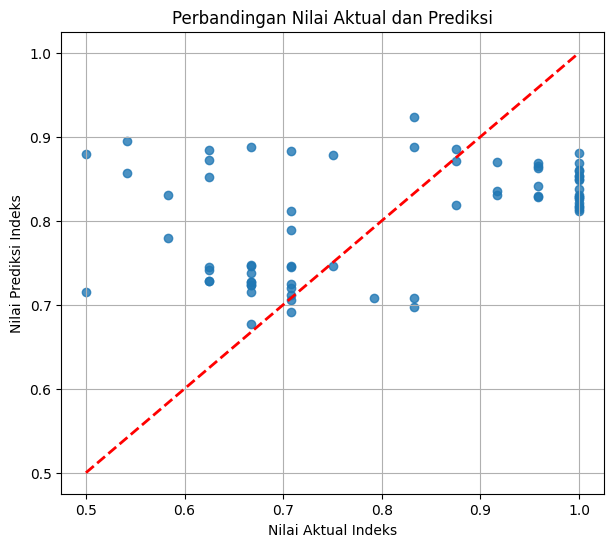

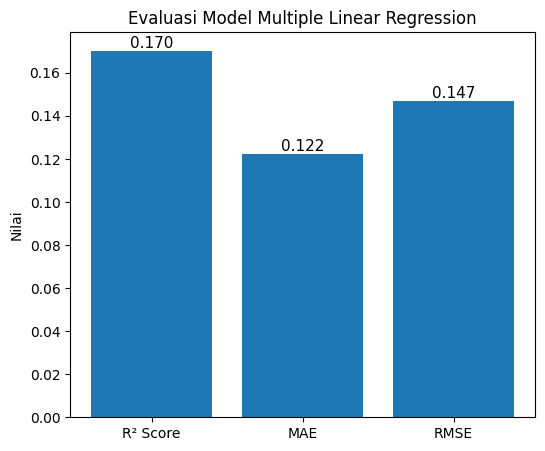

In [16]:
import matplotlib.pyplot as plt

# Grafik 1( Actual vs Predicted)
plt.figure(figsize=(7,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.8
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Nilai Aktual Indeks")
plt.ylabel("Nilai Prediksi Indeks")
plt.title("Perbandingan Nilai Aktual dan Prediksi")

plt.grid(True)

plt.savefig("grafik_actual_vs_predicted.png", dpi=300)

plt.show()


# Grafik 2 (Evaluasi Model)
plt.figure(figsize=(6,5))

metric_names = ["R² Score","MAE","RMSE"]
metric_values = [r2, mae, rmse]

bars = plt.bar(metric_names, metric_values)

plt.title("Evaluasi Model Multiple Linear Regression")
plt.ylabel("Nilai")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.savefig("grafik_evaluasi_model.png", dpi=300)

plt.show()

In [17]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from statsmodels.stats.outliers_influence import variance_inflation_factor

# ============================================
# Membaca dataset
# ============================================
df = pd.read_excel("dataset_sawi_final.xlsx")

# ============================================
# Variabel
# ============================================
X = df[["pH","kelembaban","suhu","N","P","K"]]
y = df["Indeks"]

# ============================================
# Train Test Split
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ============================================
# Training MLR
# ============================================
model = LinearRegression()

model.fit(X_train, y_train)

# ============================================
# Prediksi
# ============================================
y_pred = model.predict(X_test)

# ============================================
# Evaluasi Model
# ============================================
r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("===== Evaluasi Model =====")
print(f"R2 Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"RMSE     : {rmse:.4f}")

# ============================================
# Koefisien
# ============================================
print("\n===== Persamaan MLR =====")

print("Intercept =", model.intercept_)

for i, coef in enumerate(model.coef_, start=1):
    print(f"b{i} =", coef)

# ============================================
# Correlation Matrix
# ============================================
print("\n===== Correlation Matrix =====")

corr = df[
    ["pH","kelembaban","suhu","N","P","K","Indeks"]
].corr()

print(corr)

# ============================================
# VIF
# ============================================
print("\n===== VIF =====")

vif = pd.DataFrame()

vif["Variabel"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

===== Evaluasi Model =====
R2 Score : 0.1703
MAE      : 0.1224
RMSE     : 0.1469

===== Persamaan MLR =====
Intercept = 0.8137277037836876
b1 = -0.005945827353018609
b2 = 0.00010085508740246977
b3 = -0.0006055533772171127
b4 = 0.0003143587701167264
b5 = -0.0010875560595310953
b6 = 0.0005353385149273968

===== Correlation Matrix =====
                  pH  kelembaban      suhu         N         P         K  \
pH          1.000000   -0.066676  0.051320 -0.354872  0.021684 -0.315895   
kelembaban -0.066676    1.000000  0.008626 -0.030482  0.345714  0.085905   
suhu        0.051320    0.008626  1.000000 -0.153219  0.168698 -0.142248   
N          -0.354872   -0.030482 -0.153219  1.000000 -0.271572  0.643564   
P           0.021684    0.345714  0.168698 -0.271572  1.000000  0.061856   
K          -0.315895    0.085905 -0.142248  0.643564  0.061856  1.000000   
Indeks     -0.151581   -0.023105 -0.164152  0.324877 -0.307022  0.251767   

              Indeks  
pH         -0.151581  
kelembaba